# Hacker News Predictive Model

APAN 5205 Team Project — Athena's part

This notebook used this file (`data/hn_with_clusters.csv`) feeds into the prediction notebook.

---
## Summary

**Findings:**
- Random Forest and Decision Tree got similar RMSE around 1.11
---


<h2>Read Data</h2>

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
!pip install nltk
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_csv('aml 5205project/hn_with_clusters.csv')
df

,objectID,title,url,author,score,num_comments,summary,summary_source,summary_length,created_at,...,year_month,day_of_week,hour,is_weekend,title_length,title_word_count,has_url,has_text,story_type,cluster
0,43213612,An update on Mozilla's terms of use for Firefox,https://blog.mozilla.org/en/products/firefox/u...,ReadCarlBarks,596,366,An update on Mozilla's terms of use for Firefox,no_meta_found,47,2025-02-28 23:59:35+00:00,...,2025-02,4,23,0,47,9,1,0,external,6
1,43213583,It Was an Ambush,https://www.theatlantic.com/ideas/archive/2025...,dtquad,95,58,It Was an Ambush,no_meta_found,16,2025-02-28 23:56:35+00:00,...,2025-02,4,23,0,16,4,1,0,external,6
2,43213563,Formation of organic glass from a human brain,https://www.nature.com/articles/s41598-025-888...,thund,14,3,Formation of organic glass from a human brain,no_meta_found,45,2025-02-28 23:54:24+00:00,...,2025-02,4,23,0,45,8,1,0,research,6
3,43213530,Bloated Department of Defense spends more mone...,https://theintercept.com/2025/02/28/musk-doge-...,sea-gold,13,2,Bloated Department of Defense spends more mone...,no_meta_found,80,2025-02-28 23:52:16+00:00,...,2025-02,4,23,0,80,12,1,0,external,6
4,43213504,European leaders show support for Zelenskiy af...,https://www.reuters.com/world/europe/european-...,sirolimus,49,13,European leaders show support for Zelenskiy af...,no_meta_found,61,2025-02-28 23:50:10+00:00,...,2025-02,4,23,0,61,9,1,0,news_major,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14335,47212711,Customer Intelligence Protocol,https://github.com/Cole-Cant-Code/CIP-Customer...,ColeW,1,1,Customer Intelligence Protocol,no_meta_found,30,2026-03-02 01:18:11+00:00,...,2026-03,0,1,0,30,3,1,0,github,6
14336,47212693,Show HN: Leyoda – Shareable startup cards with...,https://leyoda.eu,whitehatd,1,1,"Hey HN, I built Leyoda — founders create an in...",story_text,763,2026-03-02 01:15:36+00:00,...,2026-03,0,1,0,56,9,1,1,show_hn,6
14337,47212692,Show HN: BeatCanvas – A browser-based demoscen...,https://beatcanvas.net/,fsrc,1,1,Show HN: BeatCanvas – A browser-based demoscen...,no_meta_found,73,2026-03-02 01:15:30+00:00,...,2026-03,0,1,0,73,10,1,0,show_hn,6
14338,47212631,Show HN: EWA Compare – Compare 21 earned wage ...,https://www.earnedwageaccess.com,Bielrv,1,0,I built a free directory and comparison tool f...,story_text,551,2026-03-02 01:06:44+00:00,...,2026-03,0,1,0,72,12,1,1,show_hn,6


In [87]:
df['log_score'] = np.log1p(df['score'])

## Custom Stopword List

In [88]:
base_stops = set(stopwords.words('english'))

hn_meta = {
    'hn', 'hacker', 'news',           
    'show', 'ask', 'tell', 'launch',  
    'comment', 'post', 'thread', 'page',
}


generic_words = {
    # verbs
    'use', 'used', 'using', 'uses',
    'make', 'made', 'making',
    'get', 'got', 'getting',
    'run', 'runs', 'running',
    'work', 'works', 'working', 'worked',
    'need', 'needs', 'find', 'found',
    'want', 'wants', 'take', 'took',
    'go', 'goes', 'going', 'come', 'coming',
    'say', 'says', 'said', 'think', 'know',
    'look', 'looks', 'help', 'start', 'stop',
    'build', 'built', 'write', 'written',
    'share', 'back', 'let', 'put', 'give',
    # adjectives / quantifiers
    'new', 'old', 'big', 'large', 'small', 'good',
    'great', 'best', 'better', 'first', 'last',
    'free', 'open', 'right', 'long', 'high', 'low',
    'real', 'full', 'simple', 'fast', 'easy',
    # time words
    'year', 'years', 'month', 'months', 'week', 'weeks',
    'day', 'days', 'time', 'times', 'today', 'now', 'just',
    # announcement / release language (every product has these)
    'release', 'released', 'version', 'update', 'updated',
    'launch', 'launched', 'launches', 'announce', 'announced',
    'report', 'reports', 'introduces', 'unveils',
    # misc noise
    'us', 'uk', 'via', 'way', 'ways', 'part', 'case',
    'thing', 'things', 'people', 'world', 'also',
    # contractions (survive punctuation stripping)
    'dont', 'cant', 'isnt', 'arent', 'wasnt', 'wont',
    'doesnt', 'didnt', 'wouldnt', 'couldnt', 'shouldnt',
    'youre', 'theyre', 'ive', 'thats', 'whats',
}

ALL_STOPS = base_stops | hn_meta | generic_words

print(f'Total stopwords: {len(ALL_STOPS)}')
print(f'Custom additions: {len(hn_meta) + len(generic_words)} words on top of NLTK base')

Total stopwords: 332
Custom additions: 137 words on top of NLTK base


In [89]:
lemmatizer = WordNetLemmatizer()

PREFIX_PATTERN = re.compile(
    r'^(show\s+hn|ask\s+hn|tell\s+hn|launch\s+hn)[:\-–]?\s*',
    flags=re.IGNORECASE
)

def clean_title(text):
    if not isinstance(text, str) or not text.strip():
        return ''

    text = PREFIX_PATTERN.sub('', text)

    text = text.lower()

    text = re.sub(r'https?\S+', '', text)

    text = re.sub(r'\d+', '', text)

    
    text = text.translate(str.maketrans('', '', string.punctuation))

    
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if len(w) > 2 and w not in ALL_STOPS
    ]

    tokens = [t for t in tokens if t not in ALL_STOPS]

    return ' '.join(tokens)

df['title_clean'] = df['title'].apply(clean_title)

df[['title', 'title_clean']].sample(8, random_state=7)

,title,title_clean
7958,Apple Desktop Bus Protocol (2021),apple desktop bus protocol
12321,I Built Grammarly for Prompts,grammarly prompt
12593,Microsoft Authenticator Will Stop Supporting P...,microsoft authenticator supporting password
2864,Show HN: Fingerprinting.my – See how unique th...,fingerprintingmy see unique browser
6202,Behind y-s2: serverless multiplayer rooms,behind serverless multiplayer room
4752,The Shadow Economy of Critical Mineral Exports,shadow economy critical mineral export
9036,Odoo: Open-Source ERP,odoo opensource erp
8634,Boiling Water,boiling water


<h2>Split Data</h2>

In [97]:
y = df['log_score']

df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at')

split_date = pd.Timestamp('2026-01-30 16:46:00', tz='UTC')
train = df[df['created_at'] <= split_date]
test = df[df['created_at'] > split_date]
X_train=train.title_clean
y_train=train.log_score

X_test=test.title_clean
y_test=test.log_score

<h2>Document Term Matrix</h2>

In [98]:
from sklearn.feature_extraction.text import CountVectorizer
tf_vectorizer = CountVectorizer(lowercase = True, stop_words = 'english',ngram_range=(1,1))
tf_vectorizer.fit(X_train)
X_train_tf = tf_vectorizer.transform(X_train)
X_test_tf = tf_vectorizer.transform(X_test)


In [99]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
tree = DecisionTreeRegressor(
    max_depth=10,            
    min_samples_leaf=20,    
    random_state=42
)
tree.fit(X_train_tf, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [100]:
y_train.head(10)

0    5.192957
1    4.174387
2    1.098612
3    1.098612
4    1.098612
5    1.098612
6    2.197225
7    2.484907
8    2.079442
9    1.098612
Name: log_score, dtype: float64

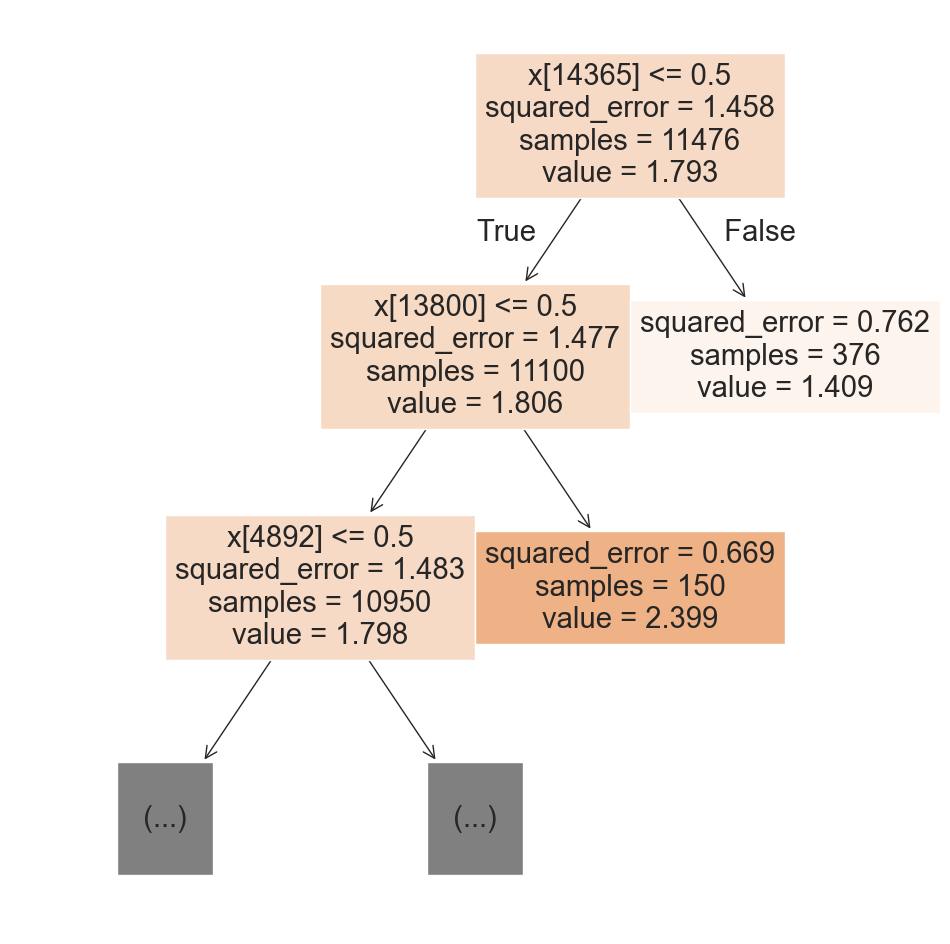

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,12))
plot_tree(tree,max_depth=2,filled=True,)
plt.show()

In [125]:
from sklearn.metrics import root_mean_squared_error
pred = tree.predict(X_test_tf)
rmse=root_mean_squared_error(y_test, pred)
rmse

1.1105266416732802

In [106]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=12, 
    n_jobs=-1, 
    random_state=42
)
rf.fit(X_train_tf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [123]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],     
    'max_depth': [10, 15, 20],       
    'min_samples_leaf': [10, 20],    
    'max_features': ['sqrt', 0.3]   
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, scoring='r2', verbose=2)
grid_search.fit(X_train_tf, y_train)

print("best：", grid_search.best_params_)
print("brst R2：", grid_search.best_score_)

best_rf = grid_search.best_estimator_
test_pred = best_rf.predict(X_test_tf)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=10, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=10, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=10, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=10, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqr

In [113]:
rmse=root_mean_squared_error(y_test, test_pred)
rmse

1.1079167222678186

In [124]:
#train
train_pred = best_rf.predict(X_train_tf)
rmse=root_mean_squared_error(y_train, train_pred)
rmse

1.1833033912009003